# Pytorch 환경확인

In [1]:
import torch
print("PyTorch 버전:", torch.__version__)
print("CUDA 사용 가능 여부:", torch.cuda.is_available()) 
print("사용 가능한 GPU 수:", torch.cuda.device_count())
print("GPU 이름:", torch.cuda.get_device_name(0))

PyTorch 버전: 2.6.0+cu124
CUDA 사용 가능 여부: True
사용 가능한 GPU 수: 1
GPU 이름: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
#!pip install -U scikit-learn

In [3]:
# iris 데이터셋 로드
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [4]:
# 재현성 고정 
torch.manual_seed(1)
# 데이터 로드 
iris = load_iris()
X = iris.data
y = iris.target
X.shape ,y.shape

((150, 4), (150,))

In [5]:
# train/test 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1,stratify=y)


In [6]:
# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Tensor로 데이터 변환(ndarray -> Tensor)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


In [8]:
# Dataset과 DataLoader 생성
train_dataset = TensorDataset(X_train_tensor, y_train_tensor) 
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [9]:
# 모델정의
class IrisNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 16) 
        self.relu = nn.ReLU() 
        self.fc2 = nn.Linear(16, 3)
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x    

In [10]:
model = IrisNet()
model

IrisNet(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=3, bias=True)
)

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [12]:
#학습 루프
epcochs = 1000
loss_history = []

for epoch in range(epcochs):
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * X_batch.size(0)
    epoch_loss /= len(train_loader.dataset)
    loss_history.append(epoch_loss)
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epcochs}, Loss: {epoch_loss:.4f}")

Epoch 10/1000, Loss: 0.2190
Epoch 20/1000, Loss: 0.1046
Epoch 30/1000, Loss: 0.0758
Epoch 40/1000, Loss: 0.0643
Epoch 50/1000, Loss: 0.0604
Epoch 60/1000, Loss: 0.0556
Epoch 70/1000, Loss: 0.0530
Epoch 80/1000, Loss: 0.0525
Epoch 90/1000, Loss: 0.0497
Epoch 100/1000, Loss: 0.0477
Epoch 110/1000, Loss: 0.0461
Epoch 120/1000, Loss: 0.0482
Epoch 130/1000, Loss: 0.0444
Epoch 140/1000, Loss: 0.0451
Epoch 150/1000, Loss: 0.0553
Epoch 160/1000, Loss: 0.0457
Epoch 170/1000, Loss: 0.0489
Epoch 180/1000, Loss: 0.0431
Epoch 190/1000, Loss: 0.0488
Epoch 200/1000, Loss: 0.0452
Epoch 210/1000, Loss: 0.0494
Epoch 220/1000, Loss: 0.0470
Epoch 230/1000, Loss: 0.0406
Epoch 240/1000, Loss: 0.0414
Epoch 250/1000, Loss: 0.0449
Epoch 260/1000, Loss: 0.0431
Epoch 270/1000, Loss: 0.0459
Epoch 280/1000, Loss: 0.0389
Epoch 290/1000, Loss: 0.0448
Epoch 300/1000, Loss: 0.0414
Epoch 310/1000, Loss: 0.0472
Epoch 320/1000, Loss: 0.0399
Epoch 330/1000, Loss: 0.0418
Epoch 340/1000, Loss: 0.0409
Epoch 350/1000, Loss: 0

In [13]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9778


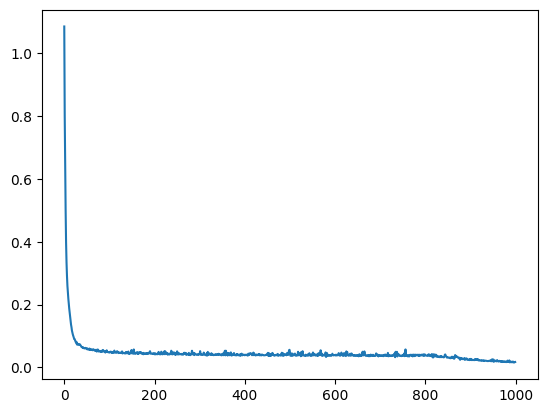

In [14]:
import matplotlib.pyplot as plt
plt.plot(loss_history)


In [17]:
# Day1-2_pytorch_mlp.ipynb

# 1. 환경 확인
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 2. 데이터셋 로드
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# 3. 모델 정의
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 비법 1: 공간의 특징을 추출하는 Conv2d 레이어
        # in_channels=1 (흑백 이미지), out_channels=32 (특징 맵 개수), kernel_size=3 (3x3 필터)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        # 비법 2: 이미지 크기를 반으로 줄여주는 MaxPool2d
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # 비법 3: Conv 레이어를 통과한 후의 크기를 계산하여 Linear 레이어와 연결
        # 28x28 이미지가 2번의 풀링(2x2)을 거치면 7x7 크기가 됩니다.
        # 채널 수는 conv2의 출력인 64개이므로, 64 * 7 * 7을 입력으로 받습니다.
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # 1. 첫 번째 합성곱 & 풀링: (배치, 1, 28, 28) -> (배치, 32, 14, 14)
        x = self.pool(F.relu(self.conv1(x)))
        
        # 2. 두 번째 합성곱 & 풀링: (배치, 32, 14, 14) -> (배치, 64, 7, 7)
        x = self.pool(F.relu(self.conv2(x)))
        
        # 3. Flatten: 2D 특징 맵을 1D로 쫙 펴주기 (MLP와 달리 여기서 펴줍니다!)
        x = x.view(-1, 64 * 7 * 7) 
        
        # 4. 완전 연결 계층 (Fully Connected Layer)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = MLP().to(device)

# 4. 손실함수와 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 5. 학습 루프
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

# 6. 평가
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")



PyTorch: 2.6.0+cu124
CUDA available: True
Using device: cuda
Epoch 1/10, Loss: 0.3381
Epoch 2/10, Loss: 0.1517
Epoch 3/10, Loss: 0.1111
Epoch 4/10, Loss: 0.0892
Epoch 5/10, Loss: 0.0755
Epoch 6/10, Loss: 0.0670
Epoch 7/10, Loss: 0.0605
Epoch 8/10, Loss: 0.0530
Epoch 9/10, Loss: 0.0465
Epoch 10/10, Loss: 0.0407
Test Accuracy: 97.54%
